Må ha minst to dataset

Filtrering og visualisering av veinett i Kristiansand

I denne analysen undersøker jeg veinettet i Kristiansand. Målet er å filtrere ut europaveier og riksveier og visualisere disse for å få en oversikt over viktige transportårer i området.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

Hente inn veinettdata

Her henter jeg veinettdata for Kristiansand fra OpenStreetMap ved hjelp av OSMnx. Datasettet lastes inn som en GeoDataFrame slik at det kan filtreres og visualiseres videre.

In [2]:
place = "Kristiansand, Norway"

G = ox.graph_from_place(place, network_type="drive")
veier = ox.graph_to_gdfs(G, nodes=False)

veier.head()

osmid  \
u        v          key                                                      
26598211 461283730  0    [33076745, 541953642, 38847118, 541953648, 553...   
26598222 936605326  0                                            787191798   
         520477758  0                                           1133780030   
26598271 1171919210 0                   [23711578, 1332680260, 1013077591]   
26600053 5233592133 0                                             38908768   

                        bridge     highway   lanes  maxspeed  oneway   ref  \
u        v          key                                                      
26598211 461283730  0      yes    motorway  [2, 3]  [90, 80]    True  E 18   
26598222 936605326  0      NaN  trunk_link     NaN        80    True  E 18   
         520477758  0      NaN       trunk       2        80    True  E 18   
26598271 1171919210 0      NaN       trunk       2        60    True  E 39   
26600053 5233592133 0      NaN     primary       2        50    True   498   

                        reversed       length  \
u        v          key                         
26598211 461283730  0      False  1247.244036   
26598222 936605326  0      False   257.041001   
         520477758  0      False   259.085906   
26598271 1171919210 0      False   577.984963   
26600053 5233592133 0      False    18.037133   

                                                                  geometry  \
u        v          key                                                      
26598211 461283730  0    LINESTRING (8.10687 58.17057, 8.10734 58.17124...   
26598222 936605326  0    LINESTRING (8.08873 58.16528, 8.08929 58.16533...   
         520477758  0    LINESTRING (8.08873 58.16528, 8.09042 58.16557...   
26598271 1171919210 0    LINESTRING (7.97783 58.14132, 7.97751 58.14129...   
26600053 5233592133 0    LINESTRING (8.133 58.17823, 8.13303 58.17828, ...   

                                name    junction width tunnel access service  
u        v          key                                                       
26598211 461283730  0            NaN         NaN   NaN    NaN    NaN     NaN  
26598222 936605326  0            NaN         NaN   NaN    NaN    NaN     NaN  
         520477758  0            NaN         NaN   NaN    NaN    NaN     NaN  
26598271 1171919210 0    Vesterveien         NaN   NaN    NaN    NaN     NaN  
26600053 5233592133 0            NaN  roundabout   NaN    NaN    NaN     NaN

## 🔎 Filtrering av europaveier og riksveier

I denne delen filtreres veinettet på `ref`-kolonnen.
- **Europaveier** identifiseres med `E`
- **Riksveier** identifiseres med veinummer `9` og `41`

Dette gjør at hovedtransportårene skiller seg tydeligere ut i kartet.

In [3]:
europaveier = veier[veier["ref"].astype(str).str.contains("E", na=False)]
riksveier = veier[veier["ref"].astype(str).str.contains(r"\b9\b|\b41\b", na=False)]

print("Antall europavei-segmenter:", len(europaveier))
print("Antall riksvei-segmenter:", len(riksveier))

Antall europavei-segmenter: 276
Antall riksvei-segmenter: 231


Visualisering

Her visualiseres hele veinettet i grått, mens europaveier vises i rødt og riksveier i blått. Dette gjør det lettere å identifisere de viktigste hovedveiene i Kristiansand.

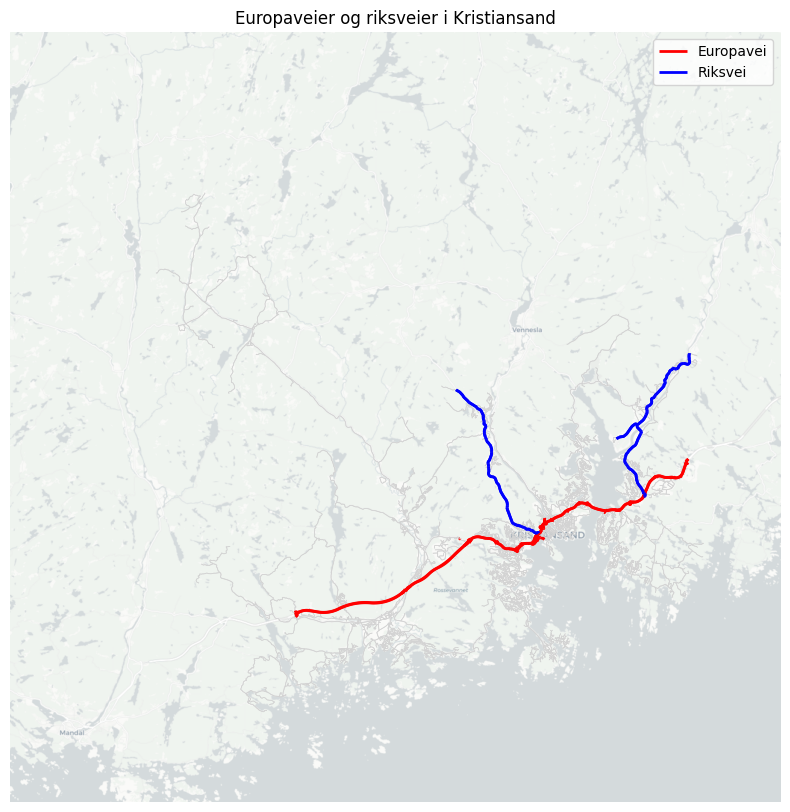

In [4]:
import contextily as ctx

# Reprojiser til Web Mercator for bakgrunnskart (samme stil som webprosjektet)
veier_3857 = veier.to_crs(epsg=3857)
europaveier_3857 = europaveier.to_crs(epsg=3857)
riksveier_3857 = riksveier.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

veier_3857.plot(ax=ax, linewidth=0.5, color="lightgrey", zorder=3)
europaveier_3857.plot(ax=ax, linewidth=2, color="red", label="Europavei", zorder=4)
riksveier_3857.plot(ax=ax, linewidth=2, color="blue", label="Riksvei", zorder=4)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=veier_3857.crs,
    zoom=11,
    reset_extent=False,
    zorder=1,
    attribution=False,
)

ax.set_title("Europaveier og riksveier i Kristiansand")
ax.set_axis_off()
ax.legend()

plt.show()

Resultat

Kartet viser europaveier og riksveier i Kristiansand. Filtreringen viser at E18 er den viktigste europaveien gjennom området, mens riksveiene 9 og 41 går nordover fra byen.

In [6]:
print("Totalt antall veisegmenter:", len(veier))
print("Antall europaveier:", len(europaveier))
print("Antall riksveier:", len(riksveier))

Totalt antall veisegmenter: 11567
Antall europaveier: 276
Antall riksveier: 231


## Import datasettene fra NVDB (ikke lokale GeoJSON-filer)

Her henter vi *to* datasett direkte fra NVDB API Les (V4-host):

- **Vegbredde** (objekttype `838`)

- **Høydebegrensning** (objekttype `591`)

Vi begrenser spørringen til en `kartutsnitt`-bbox (WGS84), og laster resultatet som `GeoDataFrame` for videre GIS-analyse.

In [7]:
from __future__ import annotations

from typing import Any
import time
import requests
import certifi

import pandas as pd
import geopandas as gpd

from shapely import wkt
from shapely.ops import transform

# Samme API-mønster som webappen (vite-proxy peker hit)
# web/vite.config.js -> https://nvdbapiles-v3.atlas.vegvesen.no
NVDB_BASE_URL = "https://nvdbapiles-v3.atlas.vegvesen.no"

# Kun API-ene du trenger
NVDB_HEIGHT_PATH = "/vegobjekter/591"
NVDB_WIDTH_PATH = "/vegobjekter/838"

# Avgrensning (bbox): xmin,ymin,xmax,ymax i EPSG:4326
BBOX_KRISTIANSAND = "7.95,58.10,8.10,58.25"
BBOX_SENTRUM = "7.98,58.137,8.03,58.160"

# For komplett kartbilde i notebook: hent samme utsnitt som vises i kartet.
BBOX_FETCH = BBOX_SENTRUM

# Paginering: viktig for å unngå ufullstendig data (API returnerer sider)
NVDB_PAGE_SIZE = 400
NVDB_MAX_PAGES = 30
NVDB_MAX_FEATURES = NVDB_PAGE_SIZE * NVDB_MAX_PAGES

NVDB_HEADERS = {
    "Accept": "application/json",
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    ),
}
NVDB_VERIFY = certifi.where()


def _swap_xy(geom):
    # NVDB srid=4326 kommer ofte som LAT LON, vi trenger LON LAT.
    return transform(lambda x, y, z=None: (y, x) if z is None else (y, x, z), geom)


def _flatten_egenskaper(egenskaper: list[dict[str, Any]] | None) -> dict[str, Any]:
    out: dict[str, Any] = {}
    for e in egenskaper or []:
        name = e.get("navn") or str(e.get("id"))
        value = e.get("verdi")
        if isinstance(value, (dict, list)):
            value = str(value)
        out[name] = value
    return out


def _get_with_retry(session: requests.Session, url: str, *, params: dict[str, Any]) -> dict[str, Any]:
    for attempt in range(1, 8):
        r = session.get(url, params=params, timeout=(20, 60), verify=NVDB_VERIFY)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            retry_s = int(retry_after) if (retry_after and retry_after.isdigit()) else 0
            wait_s = max(retry_s, min(2**attempt, 30))
            print(f"NVDB 429 (rate limit). Venter {wait_s}s og prøver igjen…")
            time.sleep(wait_s)
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError("Fikk for mange 429-responser fra NVDB.")


def fetch_nvdb_vegobjekter(path: str, bbox: str) -> list[dict[str, Any]]:
    url = f"{NVDB_BASE_URL}{path}"
    params_base = {
        "srid": 4326,
        "kartutsnitt": bbox,
        "antall": NVDB_PAGE_SIZE,
        "inkluder": "egenskaper,geometri",
    }

    start: str | None = None
    pages = 0
    out: list[dict[str, Any]] = []

    with requests.Session() as session:
        session.headers.update(NVDB_HEADERS)

        while True:
            params = dict(params_base)
            if start:
                params["start"] = start

            data = _get_with_retry(session, url, params=params)
            pages += 1

            batch = data.get("objekter", []) or []
            out.extend(batch)

            next_meta = (data.get("metadata", {}) or {}).get("neste")
            start = (next_meta or {}).get("start") if next_meta else None

            if not next_meta:
                break
            if pages >= NVDB_MAX_PAGES:
                break
            if len(out) >= NVDB_MAX_FEATURES:
                break

            time.sleep(0.2)

    return out[:NVDB_MAX_FEATURES]


def build_vegobj_features(objects: list[dict[str, Any]]) -> list[dict[str, Any]]:
    features: list[dict[str, Any]] = []
    for obj in objects:
        geom_wkt = ((obj.get("geometri") or {}).get("wkt"))
        if not geom_wkt:
            continue
        geom = _swap_xy(wkt.loads(geom_wkt))
        props = _flatten_egenskaper(obj.get("egenskaper"))
        props["nvdb_id"] = obj.get("id")
        features.append({"properties": props, "geometry": geom})
    return features


def features_to_gdf(features: list[dict[str, Any]], *, crs: str = "EPSG:4326") -> gpd.GeoDataFrame:
    rows = [f["properties"] for f in features]
    geoms = [f["geometry"] for f in features]
    df = pd.DataFrame(rows)
    return gpd.GeoDataFrame(df, geometry=geoms, crs=crs)


print("Henter NVDB Vegbredde (838)…")
width_objects = fetch_nvdb_vegobjekter(NVDB_WIDTH_PATH, BBOX_FETCH)
print(f"Vegbredde: hentet {len(width_objects)} objekter")

time.sleep(2)
print("Henter NVDB Høydebegrensning (591)…")
height_objects = fetch_nvdb_vegobjekter(NVDB_HEIGHT_PATH, BBOX_FETCH)
print(f"Høydebegrensning: hentet {len(height_objects)} objekter")

width_gdf = features_to_gdf(build_vegobj_features(width_objects), crs="EPSG:4326")
height_gdf = features_to_gdf(build_vegobj_features(height_objects), crs="EPSG:4326")

print("Vegbredde (838):", width_gdf.shape, "CRS:", width_gdf.crs)
print("Høydebegrensning (591):", height_gdf.shape, "CRS:", height_gdf.crs)

display(width_gdf.head(3))

Henter NVDB Vegbredde (838)…
Vegbredde: hentet 119 objekter
Henter NVDB Høydebegrensning (591)…
Høydebegrensning: hentet 25 objekter
Vegbredde (838): (119, 24) CRS: EPSG:4326
Høydebegrensning (591): (25, 14) CRS: EPSG:4326


,Liste av lokasjonsattributt,"Dekkebredde, maks",Dekkebredde,"Dekkebredde, min",Nøyaktighet grunnlagsdata,Beregningsinfo,"Dato grunnlagsdata, eldste",Grunnlag,Datafangstmetode FKB grunnlagsdata,nvdb_id,...,"Vegbredde, min","Kjørebanebredde, maks",Kjørebanebredde,"Kjørebanebredde, min","Dato grunnlagsdata, nyeste","Skulderbredde total, høyre","Skulderbredde asfalt, venstre","Skulderbredde total, venstre","Skulderbredde asfalt, høyre",geometry
0,None,19.94,14.7,10.87,31.0,"Avrundingsverdi=0.10, Beregningsdato=2014-07-21",2009-04-05,FKB,24,573109568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING Z (7.98198 58.145 10.934, 7.9819 58..."
1,None,9.10,7.4,6.64,31.0,"Avrundingsverdi=0.10, Beregningsdato=2014-07-21",2009-04-05,FKB,24,573109633,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING Z (7.97778 58.14625 21.236, 7.97775..."
2,None,6.98,4.2,3.66,31.0,"Avrundingsverdi=0.10, Beregningsdato=2014-07-21",2009-04-05,FKB,24,573109634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING Z (7.97899 58.14564 20.662, 7.97896..."


### Datasett som GeoDataFrame

`width_gdf` og `height_gdf` er nå klare til filtrering, buffer, overlay, aggregering osv.

In [8]:
# Enkle sjekker og kolonne-preview
print("width_gdf columns:", list(width_gdf.columns)[:20])
print("height_gdf columns:", list(height_gdf.columns)[:20])

# Typiske felter du kan bruke videre (kan variere litt):
preview_cols_width = [c for c in ["nvdb_id", "Dekkebredde", "Dekkebredde, min", "Dekkebredde, maks"] if c in width_gdf.columns]
preview_cols_height = [c for c in ["nvdb_id", "Skilta høyde", "H-min, midt", "Navn", "Type hinder"] if c in height_gdf.columns]

display(width_gdf[preview_cols_width + ["geometry"]].head(5) if preview_cols_width else width_gdf.head(5))
display(height_gdf[preview_cols_height + ["geometry"]].head(5) if preview_cols_height else height_gdf.head(5))

width_gdf columns: ['Liste av lokasjonsattributt', 'Dekkebredde, maks', 'Dekkebredde', 'Dekkebredde, min', 'Nøyaktighet grunnlagsdata', 'Beregningsinfo', 'Dato grunnlagsdata, eldste', 'Grunnlag', 'Datafangstmetode FKB grunnlagsdata', 'nvdb_id', 'Dekkebredde, median', 'Dekkebredde, normal', 'Vegbredde, maks', 'Vegbredde', 'Vegbredde, min', 'Kjørebanebredde, maks', 'Kjørebanebredde', 'Kjørebanebredde, min', 'Dato grunnlagsdata, nyeste', 'Skulderbredde total, høyre']
height_gdf columns: ['Liste av lokasjonsattributt', 'Beregnet høyde', 'Navn', 'Type hinder', 'H-min, høyre kant', 'H-min, midt', 'H-min, venstre kant', 'nvdb_id', 'Skilta høyde', 'Geometri, linje', 'Bredde', 'Måledato', 'Målemetode', 'geometry']


,nvdb_id,Dekkebredde,"Dekkebredde, min","Dekkebredde, maks",geometry
0,573109568,14.7,10.87,19.94,"LINESTRING Z (7.98198 58.145 10.934, 7.9819 58..."
1,573109633,7.4,6.64,9.10,"LINESTRING Z (7.97778 58.14625 21.236, 7.97775..."
2,573109634,4.2,3.66,6.98,"LINESTRING Z (7.97899 58.14564 20.662, 7.97896..."
3,573109635,4.2,3.66,6.98,"LINESTRING Z (7.98031 58.14513 16.507, 7.98029..."
4,573109636,4.2,3.66,6.98,"LINESTRING Z (7.9819 58.14501 10.934, 7.98184 ..."


,nvdb_id,Skilta høyde,"H-min, midt",Navn,Type hinder,geometry
0,86033923,NaN,4.60,Baneheia,Tunnel,"LINESTRING Z (7.99155 58.15042 7.635, 7.99154 ..."
1,86033926,NaN,4.79,Oddernes,Tunnel,"LINESTRING Z (8.00326 58.15619 1.015, 8.0028 5..."
2,86033929,NaN,5.39,Oddernes,Tunnel,"LINESTRING Z (8.00189 58.15552 1.735, 8.00241 ..."
3,86034454,NaN,4.60,Baneheia,Tunnel,"LINESTRING Z (7.98878 58.14876 2.8, 7.98881 58..."
4,86034457,NaN,4.60,Baneheia,Tunnel,"LINESTRING Z (7.99256 58.15513 11.714, 7.99254..."


## Overlay union

Cellen under viser **unionen av kjente veikonstriksjoner** fra NVDB:
- Vegbredde (`838`)
- Høydebegrensning (`591`)

Union-laget visualiserer samlet hvor disse registrerte restriksjonene finnes i kartutsnittet.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 20.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [contextily]1 [contextily]



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


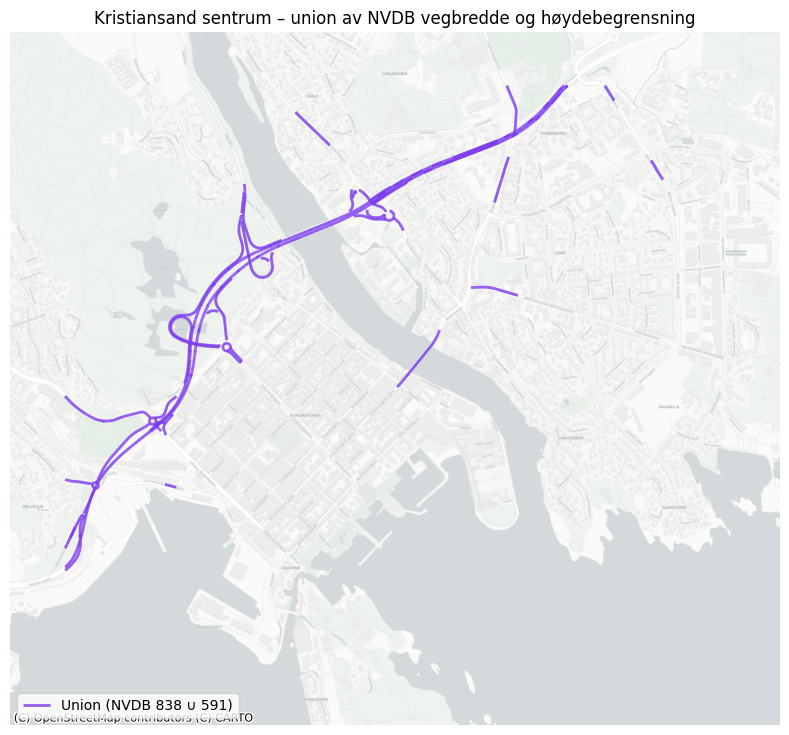

In [9]:
# Kart med bakgrunn som rendrer i notebooken (statisk bilde)
import sys
import subprocess
import os

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.ops import unary_union

# Installer contextily hvis det mangler (pip i samme kernel)
try:
    import contextily as ctx
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as ctx

# Sørg for at tile-nedlasting bruker en fungerende CA-bundle (hindrer "heng" i SSL på noen oppsett)
try:
    import certifi
    os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
    os.environ["SSL_CERT_FILE"] = certifi.where()
except Exception:
    pass


def _parse_bbox(bbox_str: str):
    xmin, ymin, xmax, ymax = [float(x) for x in bbox_str.split(",")]
    return xmin, ymin, xmax, ymax


# Bruk samme sentrum-bbox som i visualisering / fetch
xmin, ymin, xmax, ymax = _parse_bbox(BBOX_SENTRUM)
bbox_wgs84 = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:4326")

# Prosjiser til Web Mercator (EPSG:3857) for basemap tiles
bbox_3857 = bbox_wgs84.to_crs(epsg=3857)
width_3857 = width_gdf.to_crs(epsg=3857)
height_3857 = height_gdf.to_crs(epsg=3857)

minx, miny, maxx, maxy = bbox_3857.total_bounds
bbox_poly_3857 = bbox_3857.geometry.iloc[0]

# Klipp geometrier til utsnittet slik at bare det som er i kartet vises

def _clip_to_bbox(gdf: gpd.GeoDataFrame, bbox_poly):
    out = gdf.copy()
    out["geometry"] = out.geometry.intersection(bbox_poly)
    geom = out.geometry
    mask = (~geom.isna()) & (~geom.is_empty)
    out = out[mask]
    return out


width_view = _clip_to_bbox(width_3857, bbox_poly_3857)
height_view = _clip_to_bbox(height_3857, bbox_poly_3857)

# Geometrisk union av de to datasettene (838 + 591)
union_geom = unary_union(list(width_view.geometry) + list(height_view.geometry))
union_gdf = gpd.GeoDataFrame(geometry=[union_geom], crs="EPSG:3857").explode(index_parts=False, ignore_index=True)
union_gdf = union_gdf[~union_gdf.geometry.is_empty & union_gdf.geometry.notna()].copy()

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Bakgrunnskart
basemap_zoom = 16
crs_3857 = width_3857.crs.to_string()
try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        zoom=basemap_zoom,
        crs=crs_3857,
        reset_extent=False,
        zorder=0,
    )
except Exception as e:
    print("Klarte ikke å laste bakgrunnskart (tiles):", repr(e))

# Plotter union-laget som én sammenslått geometri
union_gdf.plot(
    ax=ax,
    color="#7c3aed",
    linewidth=2.0,
    alpha=0.8,
    label="Union (NVDB 838 ∪ 591)",
    zorder=6,
)

ax.set_title("Kristiansand sentrum – union av NVDB vegbredde og høydebegrensning")
ax.axis("off")
ax.legend(loc="lower left")
plt.show()

Buffersone rundt broer

Aggregering Vei tetthet inforbi et område (komune)

Kommune: Kristiansand (4204)
Areal (km²): 1,540.90
Samlet veglengde (km): 2,987.30
Veitettetthet (km/km²): 1.94


,typeVeg,length_km,tetthet_km_per_km2
0,Enkel bilveg,2032.784808,1.319218
2,Gang- og sykkelveg,301.334973,0.195558
7,Kanalisert veg,266.059702,0.172665
1,Fortau,186.819985,0.121241
4,Gangveg,104.670226,0.067928
9,Rampe,47.546282,0.030856
8,Passasjerferje,14.983347,0.009724
12,Sykkelveg,11.881185,0.007711
10,Rundkjøring,8.673359,0.005629
3,Gangfelt,7.261964,0.004713


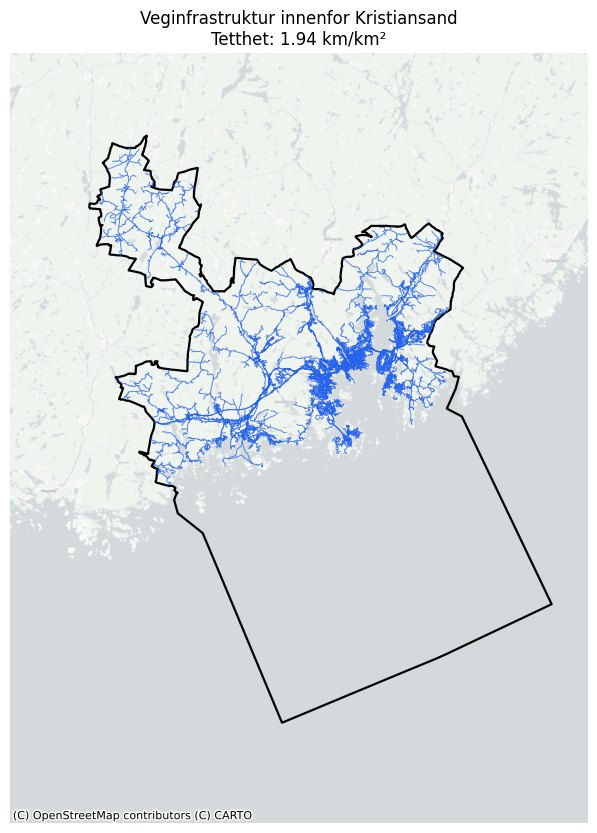

In [10]:
# Aggregering (kortversjon): veitettetthet innenfor en kommune + bakgrunnskart

import time
import requests
import certifi
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.ops import transform
from shapely.geometry import shape
import matplotlib.pyplot as plt
import contextily as ctx

NVDB_BASE_URL = "https://nvdbapiles-v3.atlas.vegvesen.no"
NVDB_HEADERS = {
    "Accept": "application/json",
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    ),
}
NVDB_VERIFY = certifi.where()
KOMMUNE_NAVN = "Kristiansand"


def _swap_xy(geom):
    return transform(lambda x, y, z=None: (y, x) if z is None else (y, x, z), geom)


def fetch_kommune_polygon(kommunenavn: str) -> gpd.GeoDataFrame:
    headers = {"User-Agent": "GIS-Notebook/1.0", "Accept": "application/json"}

    s = requests.get(
        "https://ws.geonorge.no/kommuneinfo/v1/sok",
        params={"knavn": kommunenavn},
        headers=headers,
        timeout=40,
    )
    s.raise_for_status()
    kommuner = s.json().get("kommuner", [])
    if not kommuner:
        raise ValueError(f"Fant ingen kommune med navn: {kommunenavn}")

    knr = kommuner[0]["kommunenummer"]
    knavn = kommuner[0].get("kommunenavn") or kommunenavn

    a = requests.get(
        f"https://ws.geonorge.no/kommuneinfo/v1/kommuner/{knr}/omrade",
        headers=headers,
        timeout=60,
    )
    a.raise_for_status()
    geom = shape(a.json()["omrade"])

    return gpd.GeoDataFrame(
        [{"kommunenavn": knavn, "kommunenummer": knr}],
        geometry=[geom],
        crs="EPSG:4258",
    ).to_crs("EPSG:4326")


def fetch_nvdb_roadnet_by_kommune(kommunenummer: str, antall: int = 300, max_pages: int = 80) -> list[dict]:
    url = f"{NVDB_BASE_URL}/vegnett/veglenkesekvenser"
    out: list[dict] = []
    start = None

    with requests.Session() as session:
        session.headers.update(NVDB_HEADERS)

        for _ in range(max_pages):
            params = {"srid": 4326, "kommune": kommunenummer, "antall": antall}
            if start is not None:
                params["start"] = start

            r = session.get(url, params=params, timeout=(20, 60), verify=NVDB_VERIFY)
            if not r.ok:
                raise RuntimeError(f"NVDB-feil {r.status_code}: {r.text[:220]}")

            data = r.json()
            out.extend(data.get("objekter", []) or [])

            start = ((data.get("metadata") or {}).get("neste") or {}).get("start")
            if not start:
                break
            time.sleep(0.12)

    return out


def roadnet_objects_to_gdf(objects: list[dict]) -> gpd.GeoDataFrame:
    rows, geoms = [], []
    for obj in objects:
        seq_id = obj.get("veglenkesekvensid")
        for link in obj.get("veglenker", []) or []:
            geom_wkt = ((link.get("geometri") or {}).get("wkt"))
            if not geom_wkt:
                continue
            try:
                geom = _swap_xy(wkt.loads(geom_wkt))
            except Exception:
                continue
            rows.append({"veglenkesekvensid": seq_id, "typeVeg": link.get("typeVeg", "Ukjent")})
            geoms.append(geom)

    if not rows:
        return gpd.GeoDataFrame(columns=["veglenkesekvensid", "typeVeg", "geometry"], geometry="geometry", crs="EPSG:4326")
    return gpd.GeoDataFrame(pd.DataFrame(rows), geometry=geoms, crs="EPSG:4326")


# Kjør analyse
kommune_gdf = fetch_kommune_polygon(KOMMUNE_NAVN)
kommunenavn_valgt = kommune_gdf.iloc[0]["kommunenavn"]
kommunenummer_valgt = str(kommune_gdf.iloc[0]["kommunenummer"])

roadnet_objects = fetch_nvdb_roadnet_by_kommune(kommunenummer_valgt)
roads_gdf = roadnet_objects_to_gdf(roadnet_objects)
if roads_gdf.empty:
    raise ValueError("Ingen veglenker ble hentet i valgt kommune.")

metric_crs = kommune_gdf.estimate_utm_crs()
kommune_m = kommune_gdf.to_crs(metric_crs)
roads_m = roads_gdf.to_crs(metric_crs)
roads_in_kommune = gpd.clip(roads_m, kommune_m)
roads_in_kommune = roads_in_kommune[~roads_in_kommune.geometry.is_empty & roads_in_kommune.geometry.notna()].copy()

roads_in_kommune["length_km"] = roads_in_kommune.geometry.length / 1000.0
area_km2 = float(kommune_m.geometry.area.sum() / 1_000_000.0)
total_length_km = float(roads_in_kommune["length_km"].sum())
density_km_per_km2 = total_length_km / area_km2

length_by_type = (
    roads_in_kommune.groupby("typeVeg", dropna=False, as_index=False)["length_km"]
    .sum()
    .sort_values("length_km", ascending=False)
)
length_by_type["tetthet_km_per_km2"] = length_by_type["length_km"] / area_km2

print(f"Kommune: {kommunenavn_valgt} ({kommunenummer_valgt})")
print(f"Areal (km²): {area_km2:,.2f}")
print(f"Samlet veglengde (km): {total_length_km:,.2f}")
print(f"Veitettetthet (km/km²): {density_km_per_km2:,.2f}")
display(length_by_type.head(15))

# Plot med samme bakgrunnskart som prosjektet (Carto Positron)
roads_3857 = roads_in_kommune.to_crs(epsg=3857)
kommune_3857 = kommune_m.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
kommune_3857.boundary.plot(ax=ax, linewidth=1.6, color="black", zorder=4)
roads_3857.plot(ax=ax, linewidth=0.6, alpha=0.85, color="#2563eb", zorder=5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs="EPSG:3857", zoom=11, reset_extent=False, zorder=1)
ax.set_title(f"Veginfrastruktur innenfor {kommunenavn_valgt}\nTetthet: {density_km_per_km2:.2f} km/km²")
ax.set_axis_off()
plt.show()

Raster analyser